In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [12]:
df = pd.read_csv("/Users/droogately/python_decal_fall2025/course_assignments/homework9/noisy_curvefit_data.csv")

In [13]:
print(df.shape)


(100, 6)


In [18]:
num_rows, num_cols = df.shape
print("Number of rows:", num_rows)
print("Number of columns:", num_cols)

Number of rows: 100
Number of columns: 6


In [19]:
print(df.head())

          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113


In [20]:
print(df.tail())

           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850


In [21]:
print(df.columns.tolist())

['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']


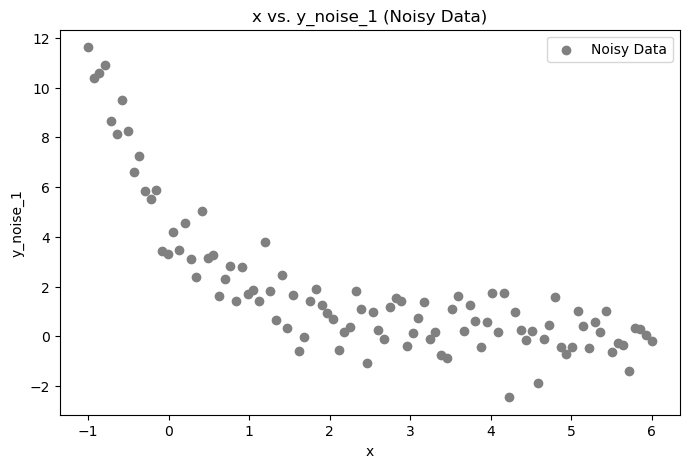

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(df["x"], df["y_noise_1"], color="gray", label="Noisy Data")

plt.xlabel("x")
plt.ylabel("y_noise_1")
plt.title("x vs. y_noise_1 (Noisy Data)")
plt.legend()
plt.show()

In [25]:
# x = df["x"].values
# y_noise_1 = df["y_noise_1"].values

In [29]:
def model(x, A, k):
    return A * np.exp(-k * x)

In [30]:
p0 = [1, 1]

In [31]:
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)

In [32]:
A_fit, k_fit = popt

In [33]:
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

Fit: y = 4.71 * e^(-0.92 * x)


In [34]:
residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)  
chi2_reduced = chi2 / dof

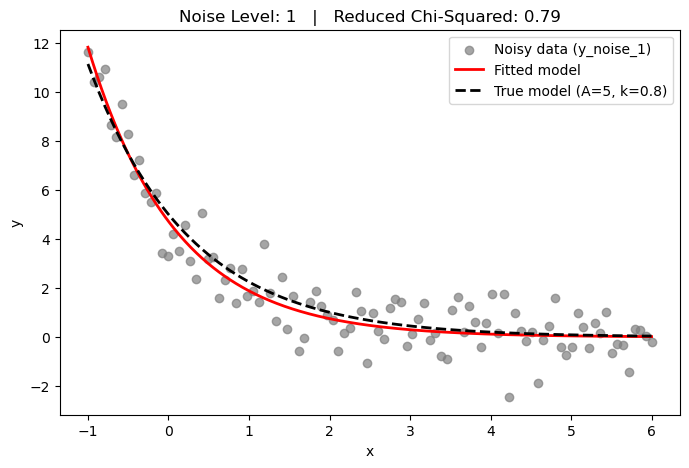

In [35]:
y_true = model(x, 5, 0.8)

x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = model(x_fit, A_fit, k_fit)

plt.figure(figsize=(8, 5))

plt.scatter(x, y_noise_1, color="gray", alpha=0.7, label="Noisy data (y_noise_1)")

plt.plot(x_fit, y_fit, color="red", linewidth=2, label="Fitted model")

plt.plot(x, y_true, color="black", linestyle="--", linewidth=2, label="True model (A=5, k=0.8)")

plt.title(f"Noise Level: 1   |   Reduced Chi-Squared: {chi2_reduced:.2f}")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


In [36]:
def fit_model(x, y):
    p0 = [1, 1]

    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt

    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)      
    chi2_reduced = chi2 / dof

    return A_fit, k_fit, chi2_reduced

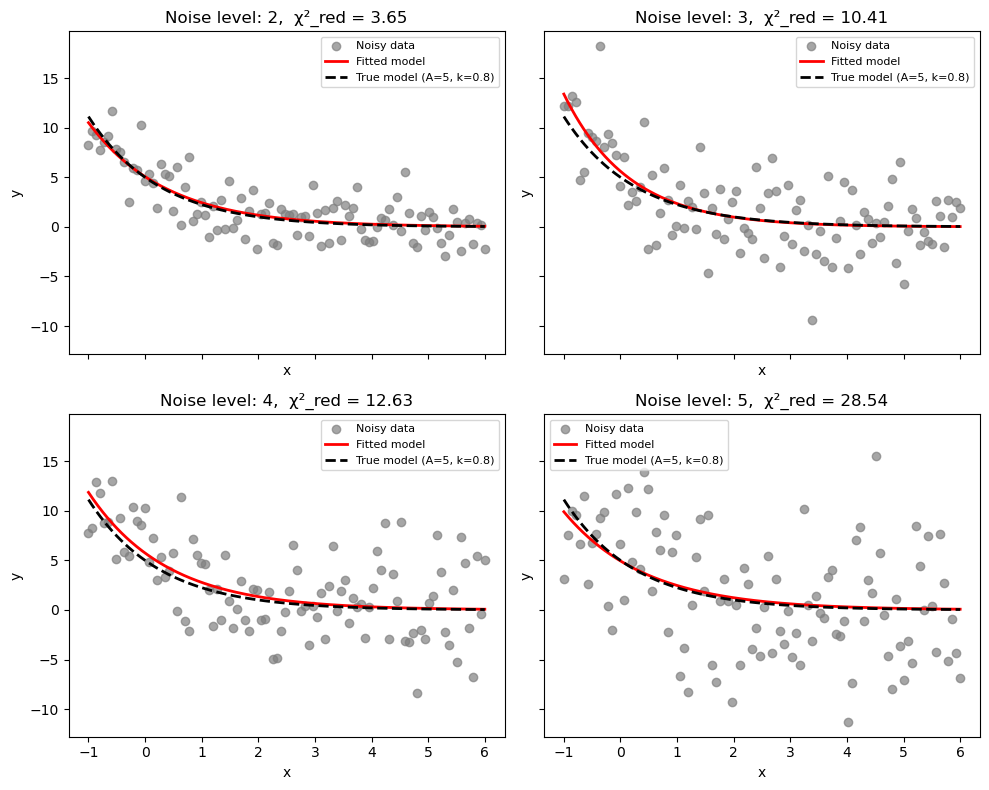

In [38]:
noise_cols = ["y_noise_2", "y_noise_3", "y_noise_4", "y_noise_5"]

y_true = model(x, 5, 0.8)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

for i, col in enumerate(noise_cols):
    ax = axes[i // 2, i % 2]

    y = df[col].values

    A_fit, k_fit, chi2_reduced = fit_model(x, y)

    x_fit = np.linspace(x.min(), x.max(), 500)
    y_fit = model(x_fit, A_fit, k_fit)


    ax.scatter(x, y, color="gray", alpha=0.7, label="Noisy data")

    ax.plot(x_fit, y_fit, color="red", linewidth=2, label="Fitted model")

    ax.plot(x, y_true, color="black", linestyle="--", linewidth=2,
            label="True model (A=5, k=0.8)")

    noise_level = col.split("_")[-1]

    ax.set_title(f"Noise level: {noise_level},  χ²_red = {chi2_reduced:.2f}")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [40]:
noise_cols = ["y_noise_1", "y_noise_2", "y_noise_3", "y_noise_4", "y_noise_5"]

results = {
    "Noise level": [],
    "A fit": [],
    "k fit": [],
    "Reduced chi-squared": []
}

for col in noise_cols:
    y = df[col].values
    A_fit, k_fit, chi2_reduced = fit_model(x, y)

    noise_level = int(col.split("_")[-1])

    results["Noise level"].append(noise_level)
    results["A fit"].append(A_fit)
    results["k fit"].append(k_fit)
    results["Reduced chi-squared"].append(chi2_reduced)

df = pd.DataFrame(results)

print(df)

   Noise level     A fit     k fit  Reduced chi-squared
0            1  4.714814  0.918308             0.790673
1            2  5.063889  0.730396             3.649382
2            3  5.609396  0.870372            10.410207
3            4  5.738727  0.725965            12.626832
4            5  4.943458  0.695012            28.538124


In [41]:
df.to_csv("noisy_parameters.csv", index=False)
